<h3><b>1. Import the Python Libraries<b></h3>

In [101]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path

PROJECT_ROOT = next(
    path for path in [Path.cwd(), *Path.cwd().parents]
    if (path / "data" / "raw" / "concrete_data.csv").exists()
)

RAW_DATA_PATH = PROJECT_ROOT / "data" / "raw" / "concrete_data.csv"
FIGURES_PATH = PROJECT_ROOT / "reports" / "figures"
FIGURES_PATH.mkdir(parents=True, exist_ok=True)

%matplotlib inline
sns.set(color_codes=True)

print("Setup Complete")

Setup Complete


<h3><b>2. Import data set from GitHub<b><h3>

In [102]:
data = pd.read_csv(RAW_DATA_PATH)

<h3><b>3. Display the first and the last 5 rows of the data <b><h3>

In [103]:
data.head()

,cement,blast_furnace_slag,fly_ash,water,superplasticizer,coarse_aggregate,fine_aggregate,age,concrete_compressive_strength
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.99
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.89
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.27
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.05
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.30


In [104]:
data.tail()

,cement,blast_furnace_slag,fly_ash,water,superplasticizer,coarse_aggregate,fine_aggregate,age,concrete_compressive_strength
1025,276.4,116.0,90.3,179.6,8.9,870.1,768.3,28,44.28
1026,322.2,0.0,115.6,196.0,10.4,817.9,813.4,28,31.18
1027,148.5,139.4,108.6,192.7,6.1,892.4,780.0,28,23.70
1028,159.1,186.7,0.0,175.6,11.3,989.6,788.9,28,32.77
1029,260.9,100.5,78.3,200.6,8.6,864.5,761.5,28,32.40


<h3><b>4. Check for the Types of the Data in the Dataset<b><h3>

In [105]:
data.shape

(1030, 9)

In [106]:
data.dtypes

cement                           float64
blast_furnace_slag               float64
fly_ash                          float64
water                            float64
superplasticizer                 float64
coarse_aggregate                 float64
fine_aggregate                   float64
age                                int64
concrete_compressive_strength    float64
dtype: object

In [107]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1030 entries, 0 to 1029
Data columns (total 9 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   cement                         1030 non-null   float64
 1   blast_furnace_slag             1030 non-null   float64
 2   fly_ash                        1030 non-null   float64
 3   water                          1030 non-null   float64
 4   superplasticizer               1030 non-null   float64
 5   coarse_aggregate               1030 non-null   float64
 6   fine_aggregate                 1030 non-null   float64
 7   age                            1030 non-null   int64  
 8   concrete_compressive_strength  1030 non-null   float64
dtypes: float64(8), int64(1)
memory usage: 72.6 KB


In [108]:
data.count()

cement                           1030
blast_furnace_slag               1030
fly_ash                          1030
water                            1030
superplasticizer                 1030
coarse_aggregate                 1030
fine_aggregate                   1030
age                              1030
concrete_compressive_strength    1030
dtype: int64

<h3><b>5. Check for Duplicate Rows <b><h3>

In [109]:
duplicate_rows = data[data.duplicated()]
print("Number of duplicate rows: ", duplicate_rows.shape)

Number of duplicate rows:  (25, 9)


<h3><b>6. Renaming the columns <b><h3>

In [110]:
data.columns = data.columns.str.strip()

data.rename(
    columns={
        "concrete_compressive_strength": "compressive_strength"
    },
    inplace=True,
)

print(data.columns.tolist())

['cement', 'blast_furnace_slag', 'fly_ash', 'water', 'superplasticizer', 'coarse_aggregate', 'fine_aggregate', 'age', 'compressive_strength']


<h3><b>7. Check for Missing Values <b><h3>

In [111]:
data.isnull().sum()

cement                  0
blast_furnace_slag      0
fly_ash                 0
water                   0
superplasticizer        0
coarse_aggregate        0
fine_aggregate          0
age                     0
compressive_strength    0
dtype: int64

<h3><b>7.1. Value Counts for Each Column <b><h3>

In [112]:
for column in data.columns:
    print(f"\nValue counts for '{column}':")
    print(data[column].value_counts(dropna=False).sort_index())


Value counts for 'cement':
cement
102.0    4
108.3    4
116.0    4
122.6    4
132.0    2
        ..
522.0    2
525.0    7
528.0    1
531.3    5
540.0    9
Name: count, Length: 278, dtype: int64

Value counts for 'blast_furnace_slag':
blast_furnace_slag
0.0      471
11.0       4
13.6       5
15.0       5
17.2       1
        ... 
290.2      2
305.3      4
316.1      2
342.1      2
359.4      2
Name: count, Length: 185, dtype: int64

Value counts for 'fly_ash':
fly_ash
0.0      566
24.5      15
59.0       1
60.0       1
71.0       1
        ... 
194.0      1
194.9      1
195.0      3
200.0      1
200.1      1
Name: count, Length: 156, dtype: int64

Value counts for 'water':
water
121.8     5
126.6     5
127.0     1
127.3     1
137.8     5
         ..
228.0    54
236.7     1
237.0     1
246.9     1
247.0     1
Name: count, Length: 195, dtype: int64

Value counts for 'superplasticizer':
superplasticizer
0.0     379
1.7       4
1.9       1
2.0       1
2.2       1
       ... 
22.0      6
22

<h3><b>8. Summary Statistics <b><h3>

In [113]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
cement,1030.0,281.167864,104.506364,102.00,192.375,272.900,350.000,540.0
blast_furnace_slag,1030.0,73.895825,86.279342,0.00,0.000,22.000,142.950,359.4
fly_ash,1030.0,54.188350,63.997004,0.00,0.000,0.000,118.300,200.1
water,1030.0,181.567282,21.354219,121.80,164.900,185.000,192.000,247.0
superplasticizer,1030.0,6.204660,5.973841,0.00,0.000,6.400,10.200,32.2
coarse_aggregate,1030.0,972.918932,77.753954,801.00,932.000,968.000,1029.400,1145.0
fine_aggregate,1030.0,773.580485,80.175980,594.00,730.950,779.500,824.000,992.6
age,1030.0,45.662136,63.169912,1.00,7.000,28.000,56.000,365.0
compressive_strength,1030.0,35.817961,16.705742,2.33,23.710,34.445,46.135,82.6


<h3><b>9. Visualization Plots - Histogram <b><h3>

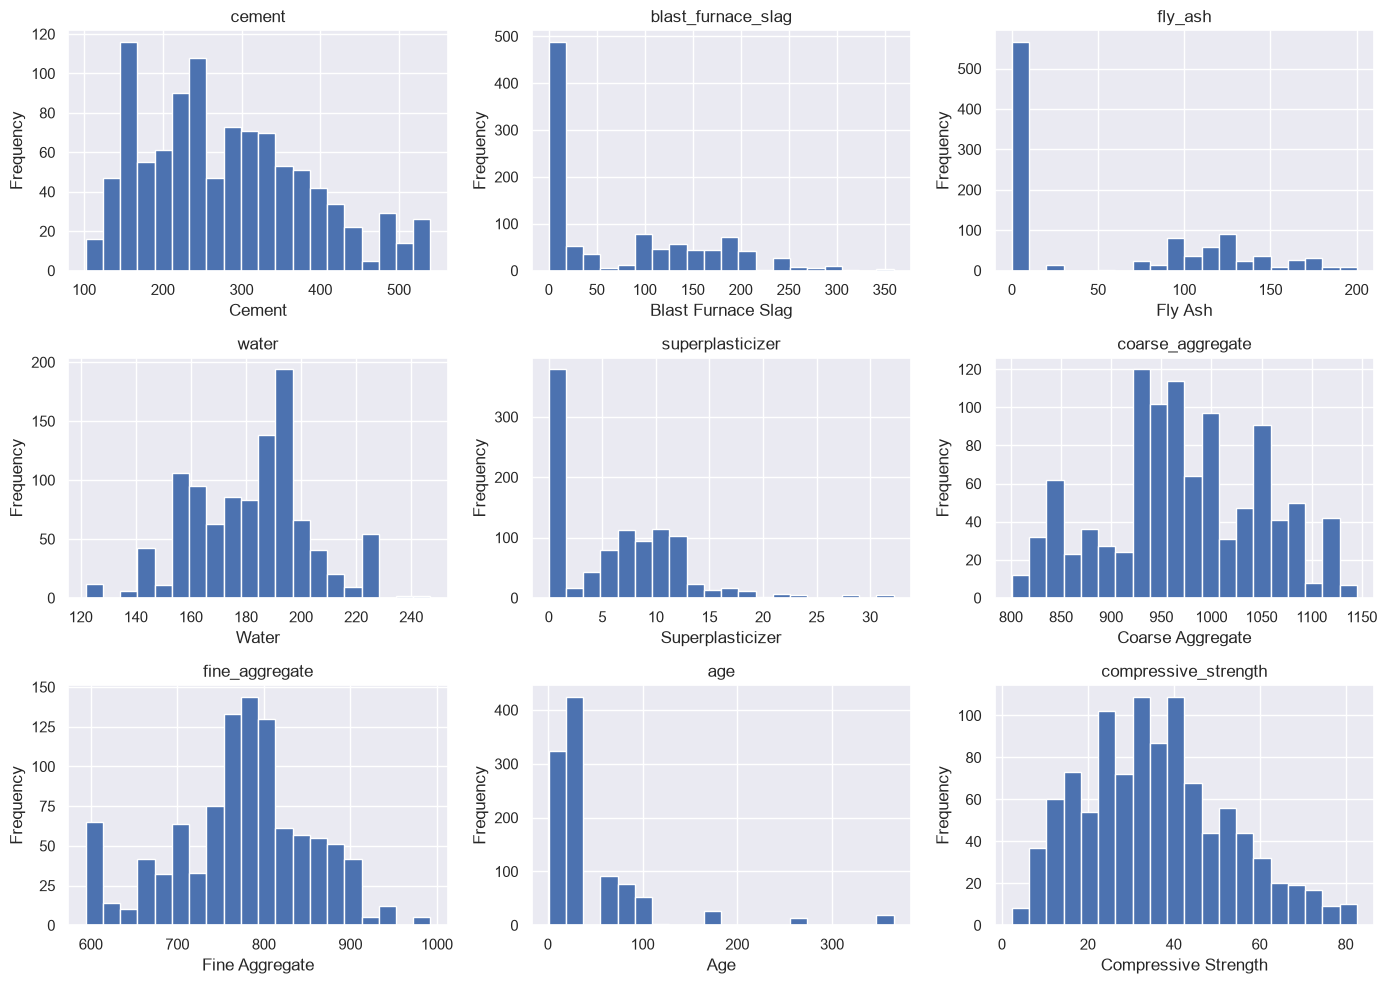

In [114]:
axes = data.hist(figsize=(14, 10), bins=20)

for axis in axes.flat:
    axis.set_xlabel(axis.get_title().replace("_", " ").title())
    axis.set_ylabel("Frequency")

plt.tight_layout()
plt.show()

<h3><b>10. Outlier Detection <b><h3>

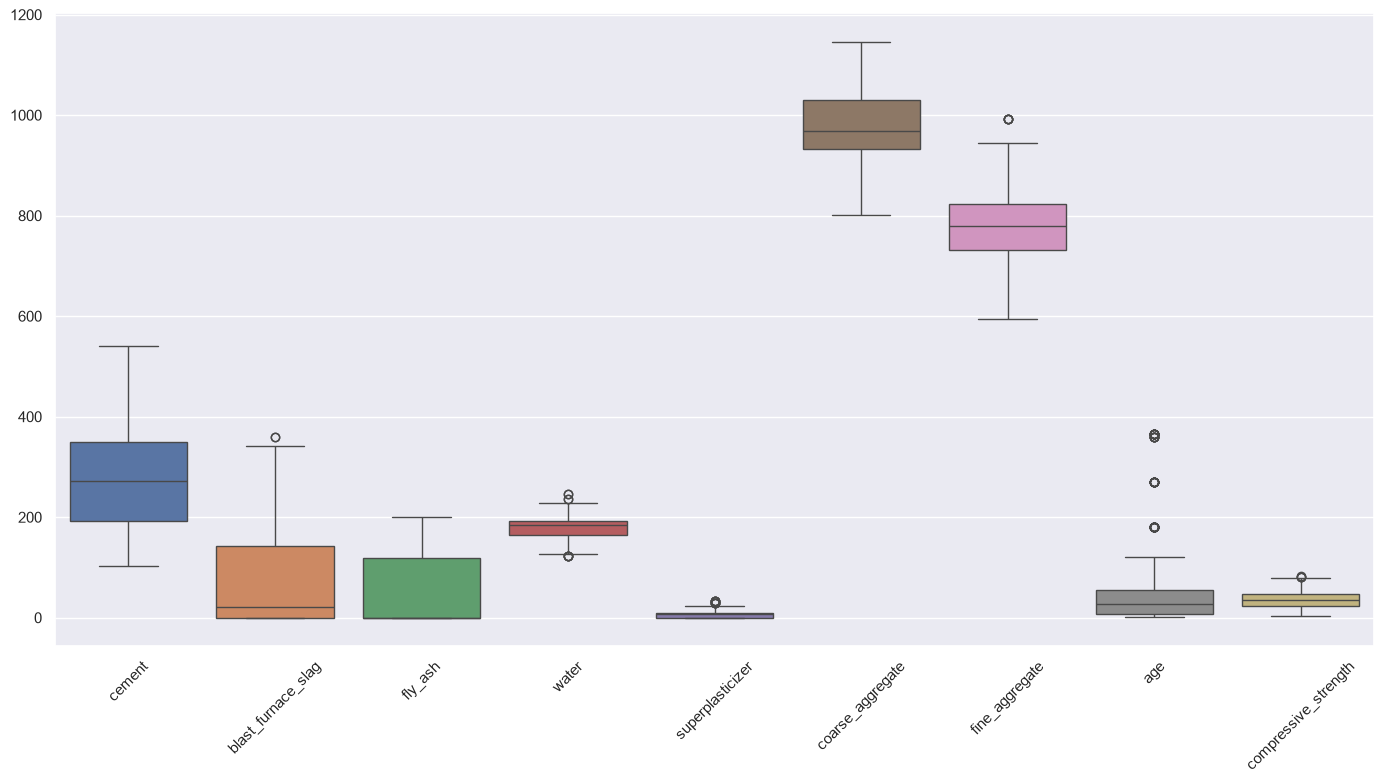

In [115]:
plt.figure(figsize=(14, 8))
sns.boxplot(data=data)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(FIGURES_PATH / "outlier_boxplots.png", dpi=300)
plt.show()
plt.close()

<h3><b>10.1. Quantify Outliers Using the IQR Method <b><h3>

In [116]:
numeric_columns = data.select_dtypes(include="number").columns

q1 = data[numeric_columns].quantile(0.25)
q3 = data[numeric_columns].quantile(0.75)
iqr = q3 - q1
lower_bounds = q1 - 1.5 * iqr
upper_bounds = q3 + 1.5 * iqr

outlier_mask = (data[numeric_columns] < lower_bounds) | (data[numeric_columns] > upper_bounds)
outlier_counts = outlier_mask.sum().sort_values(ascending=False)

print("Outlier count by column:")
print(outlier_counts[outlier_counts > 0])

outlier_rows = data[outlier_mask.any(axis=1)]
print(f"Rows containing at least one outlier: {len(outlier_rows)}")
outlier_rows.head()

Outlier count by column:
age                     59
superplasticizer        10
water                    9
fine_aggregate           5
compressive_strength     4
blast_furnace_slag       2
dtype: int64
Rows containing at least one outlier: 89


,cement,blast_furnace_slag,fly_ash,water,superplasticizer,coarse_aggregate,fine_aggregate,age,compressive_strength
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.99
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.27
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.05
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.30
6,380.0,95.0,0.0,228.0,0.0,932.0,594.0,365,43.70


<h3><b>11. Visualization Plots - Heat Map <b><h3>

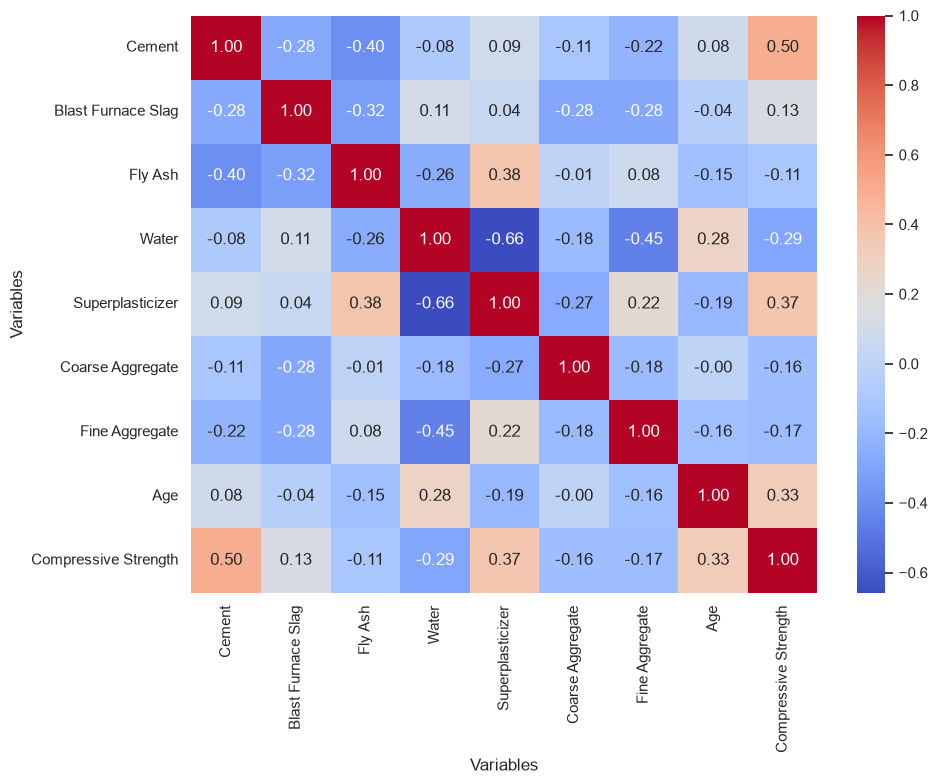

In [117]:
correlation_matrix = data.corr(numeric_only=True)

plt.figure(figsize=(10, 8))
sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    xticklabels=[column.replace("_", " ").title() for column in correlation_matrix.columns],
    yticklabels=[column.replace("_", " ").title() for column in correlation_matrix.index],
)
plt.xlabel("Variables")
plt.ylabel("Variables")
plt.tight_layout()
plt.savefig(FIGURES_PATH / "correlation_heatmap.png", dpi=300)
plt.show()
plt.close()

<h3><b>12. Visualization Plots - Scatter Plots <b><h3>

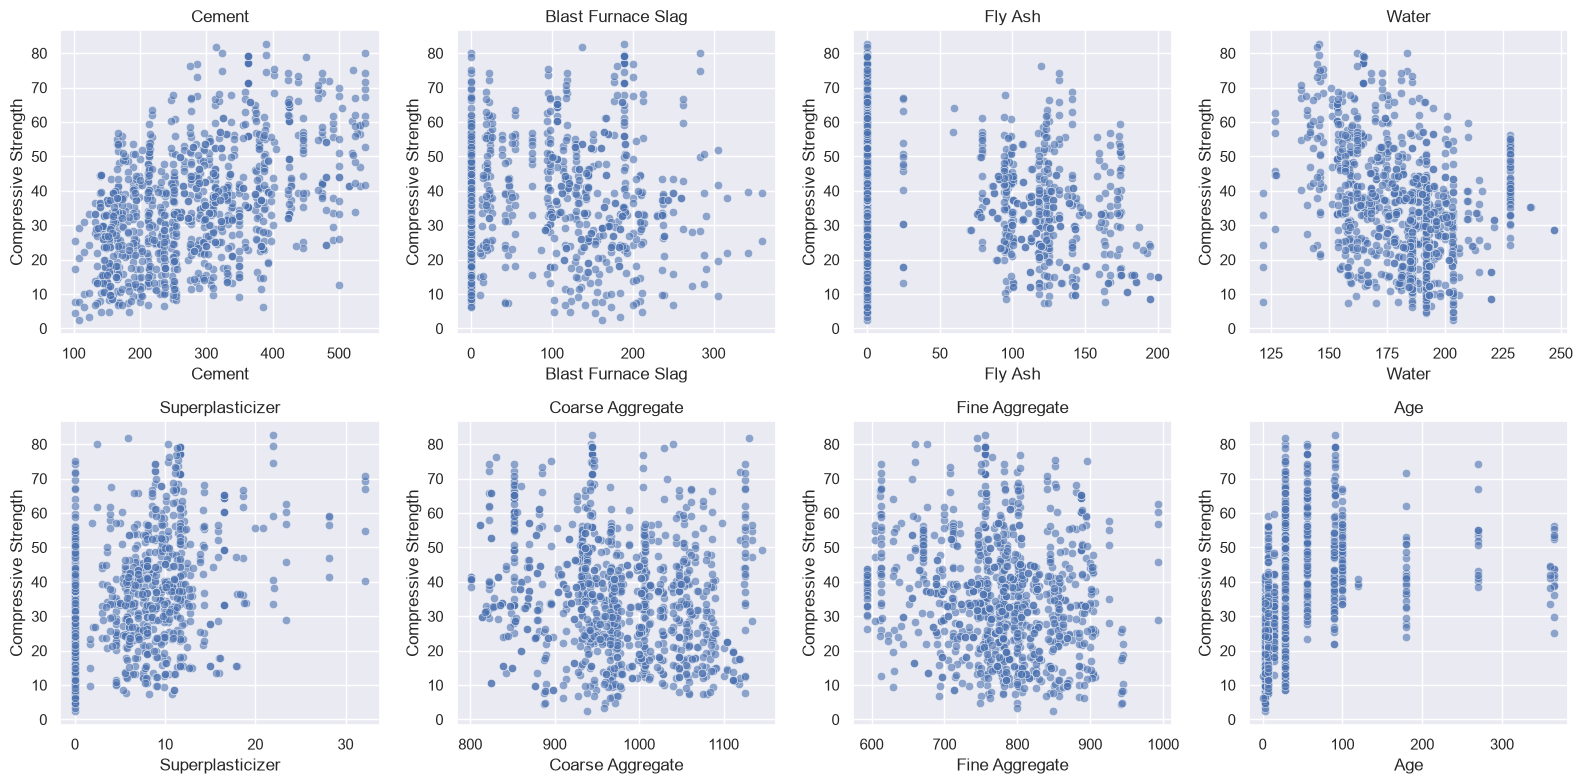

In [118]:
target = "compressive_strength"
feature_columns = [column for column in data.columns if column != target]

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for axis, feature in zip(axes.flat, feature_columns):
    sns.scatterplot(data=data, x=feature, y=target, ax=axis, alpha=0.6)
    axis.set_title(feature.replace("_", " ").title())
    axis.set_xlabel(feature.replace("_", " ").title())
    axis.set_ylabel("Compressive Strength")

plt.tight_layout()
plt.savefig(FIGURES_PATH / "feature_target_relationships.png", dpi=300)
plt.show()
plt.close()